In [133]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import math
from imblearn.over_sampling import SMOTE
from mord import LogisticAT, OrdinalRidge, LogisticIT, LogisticSE
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, matthews_corrcoef, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [134]:
RISK_MAPPING = {
    'Low Risk': 0,
    'Moderate Risk': 1,
    'High Risk': 2
}

In [135]:
df = pd.read_csv('diabetes_dataset(Threshold with References).csv', sep=',')
df.columns = df.columns.str.strip().str.replace(' ', '_')
df['Alcohol_Intake'] = df['Alcohol_Intake'].fillna('Never')
df = df.dropna().copy()
df['Risk_Level'] = df['Risk_Level'].map(RISK_MAPPING)

df.head()

,Gender,Age,Age_Potential,Age_Conversion,Physical_Activity,Smoking_Status,Alcohol_Intake,Glucose,Glucose_Potential,Glucose_Conversion,...,BMI,BMI_Potential,BMI_Conversion,Cholesterol,Diabetes_Pedigree_Function,Family_History,Hypertension,Outcome,Risk_Value,Risk_Level
0,Male,63,Middle,1,Moderate,Former,Never,103,Middle,1,...,28.20,Middle,1,167,1.39,Yes,Yes,Diabetic,1.00,1
1,Female,51,Middle,1,Moderate,Never,Regular,104,Middle,1,...,30.44,High,2,209,0.82,No,No,Diabetic,1.40,2
2,Female,74,High,2,Moderate,Current,Never,128,High,2,...,38.70,High,2,170,0.24,No,No,Diabetic,2.00,2
3,Male,78,High,2,Low,Never,Occasional,148,High,2,...,44.86,High,2,170,0.34,No,No,Diabetic,2.00,2
4,Male,32,Low,0,High,Never,Never,102,Middle,1,...,21.59,Low,0,211,1.15,Yes,No,Non-diabetic,0.35,0


In [136]:
df.isnull().sum()

Gender                        0
Age                           0
Age_Potential                 0
Age_Conversion                0
Physical_Activity             0
Smoking_Status                0
Alcohol_Intake                0
Glucose                       0
Glucose_Potential             0
Glucose_Conversion            0
Blood_Pressure                0
Skin_Thickness                0
Insulin                       0
BMI                           0
BMI_Potential                 0
BMI_Conversion                0
Cholesterol                   0
Diabetes_Pedigree_Function    0
Family_History                0
Hypertension                  0
Outcome                       0
Risk_Value                    0
Risk_Level                    0
dtype: int64

In [137]:
df.dtypes

Gender                         object
Age                             int64
Age_Potential                  object
Age_Conversion                  int64
Physical_Activity              object
Smoking_Status                 object
Alcohol_Intake                 object
Glucose                         int64
Glucose_Potential              object
Glucose_Conversion              int64
Blood_Pressure                  int64
Skin_Thickness                  int64
Insulin                         int64
BMI                           float64
BMI_Potential                  object
BMI_Conversion                  int64
Cholesterol                     int64
Diabetes_Pedigree_Function    float64
Family_History                 object
Hypertension                   object
Outcome                        object
Risk_Value                    float64
Risk_Level                      int64
dtype: object

In [138]:
df = df.drop(columns=["Risk_Value", "Outcome", "Glucose_Conversion", "Age_Conversion", "BMI_Conversion", "Age_Potential", "Glucose_Potential", "BMI_Potential"])

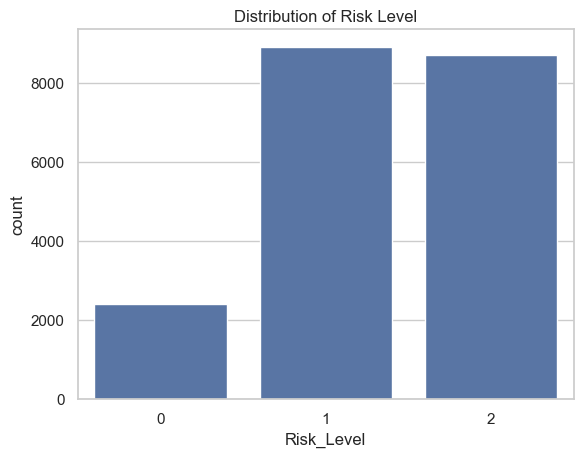

In [139]:
sns.countplot(x=df['Risk_Level'])
plt.title('Distribution of Risk Level')
plt.show()

In [140]:
X = df.drop(columns=['Risk_Level'])
y = df['Risk_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [141]:
mapping = {
    'Gender':            {'Male': 0, 'Female': 1},
    'Physical_Activity': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Smoking_Status':    {'Never': 0, 'Former': 1, 'Current': 2},
    'Alcohol_Intake':    {'Never': 0, 'Occasional': 1, 'Regular': 2},
    'Family_History':    {'No': 0, 'Yes': 1},
    'Hypertension':      {'No': 0, 'Yes': 1},
}

X_train = X_train.replace(mapping).infer_objects(copy=False)
X_test  = X_test.replace(mapping).infer_objects(copy=False)

C:\Users\asus\AppData\Local\Temp\ipykernel_6664\3450685272.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = X_train.replace(mapping).infer_objects(copy=False)
C:\Users\asus\AppData\Local\Temp\ipykernel_6664\3450685272.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test  = X_test.replace(mapping).infer_objects(copy=False)


In [142]:
std_cols = [col for col in df.select_dtypes(exclude=['object']).columns if col not in ['Risk_Level']]
cat_cols = [col for col in X_train.columns if col not in std_cols]

In [143]:
transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), std_cols)
    ],
    remainder='passthrough'
)
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

feature_names = transformer.get_feature_names_out()
feature_names = [name.split("__", 1)[1] if "__" in name else name for name in feature_names]

In [144]:
df_train = pd.DataFrame(X_train_transformed, columns=feature_names)
df_train['Risk_Level'] = y_train.values

df_test = pd.DataFrame(X_test_transformed, columns=feature_names)
df_test['Risk_Level'] = y_test.values

df_train = df_train[list(X.columns) + ['Risk_Level']]
df_test = df_test[list(X.columns) + ['Risk_Level']]

In [145]:
df_smote = df_train.copy()
smote = SMOTE(random_state=42)
X = df_smote.drop('Risk_Level', axis=1)
y = df_smote['Risk_Level']
X_smote, y_smote = smote.fit_resample(X, y)

df_smote = pd.DataFrame(X_smote, columns=X.columns)
df_smote['Risk_Level'] = y_smote.values

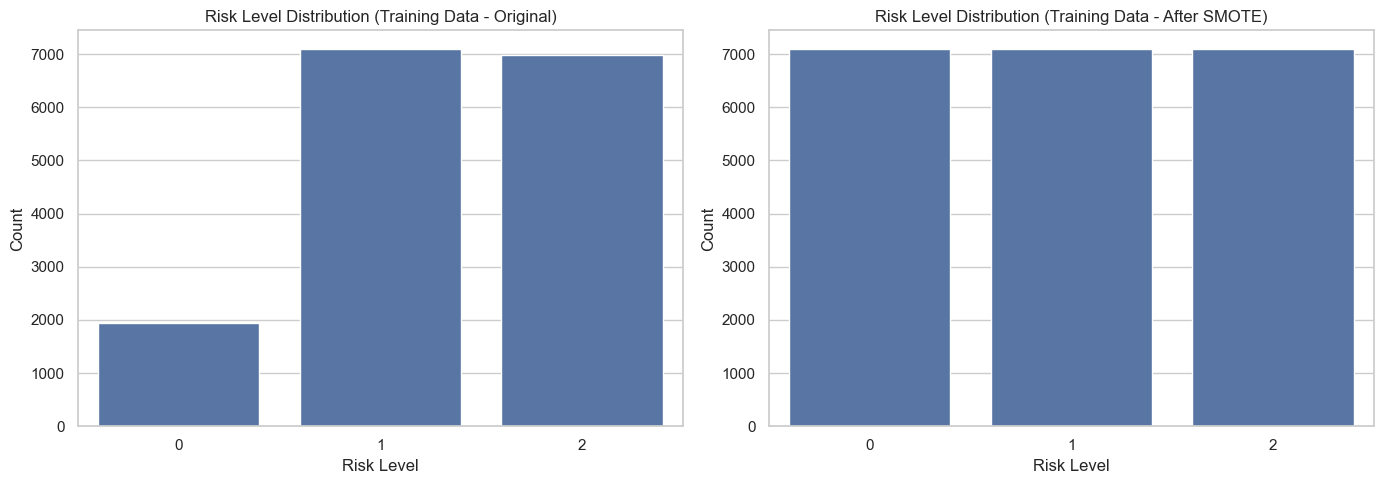

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train.values, ax=axes[0])
axes[0].set_title('Risk Level Distribution (Training Data - Original)')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')

sns.countplot(x=y_smote, ax=axes[1])
axes[1].set_title('Risk Level Distribution (Training Data - After SMOTE)')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [147]:
X_train = df_smote.drop('Risk_Level', axis=1)
y_train = df_smote['Risk_Level']

X_test = df_test.drop('Risk_Level', axis=1)
y_test = df_test['Risk_Level']

In [148]:
combined_df = pd.concat([df_smote, df_test], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

d:\Tesis\Coding\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 25273.
  res = hypotest_fun_out(*samples, **kwds)


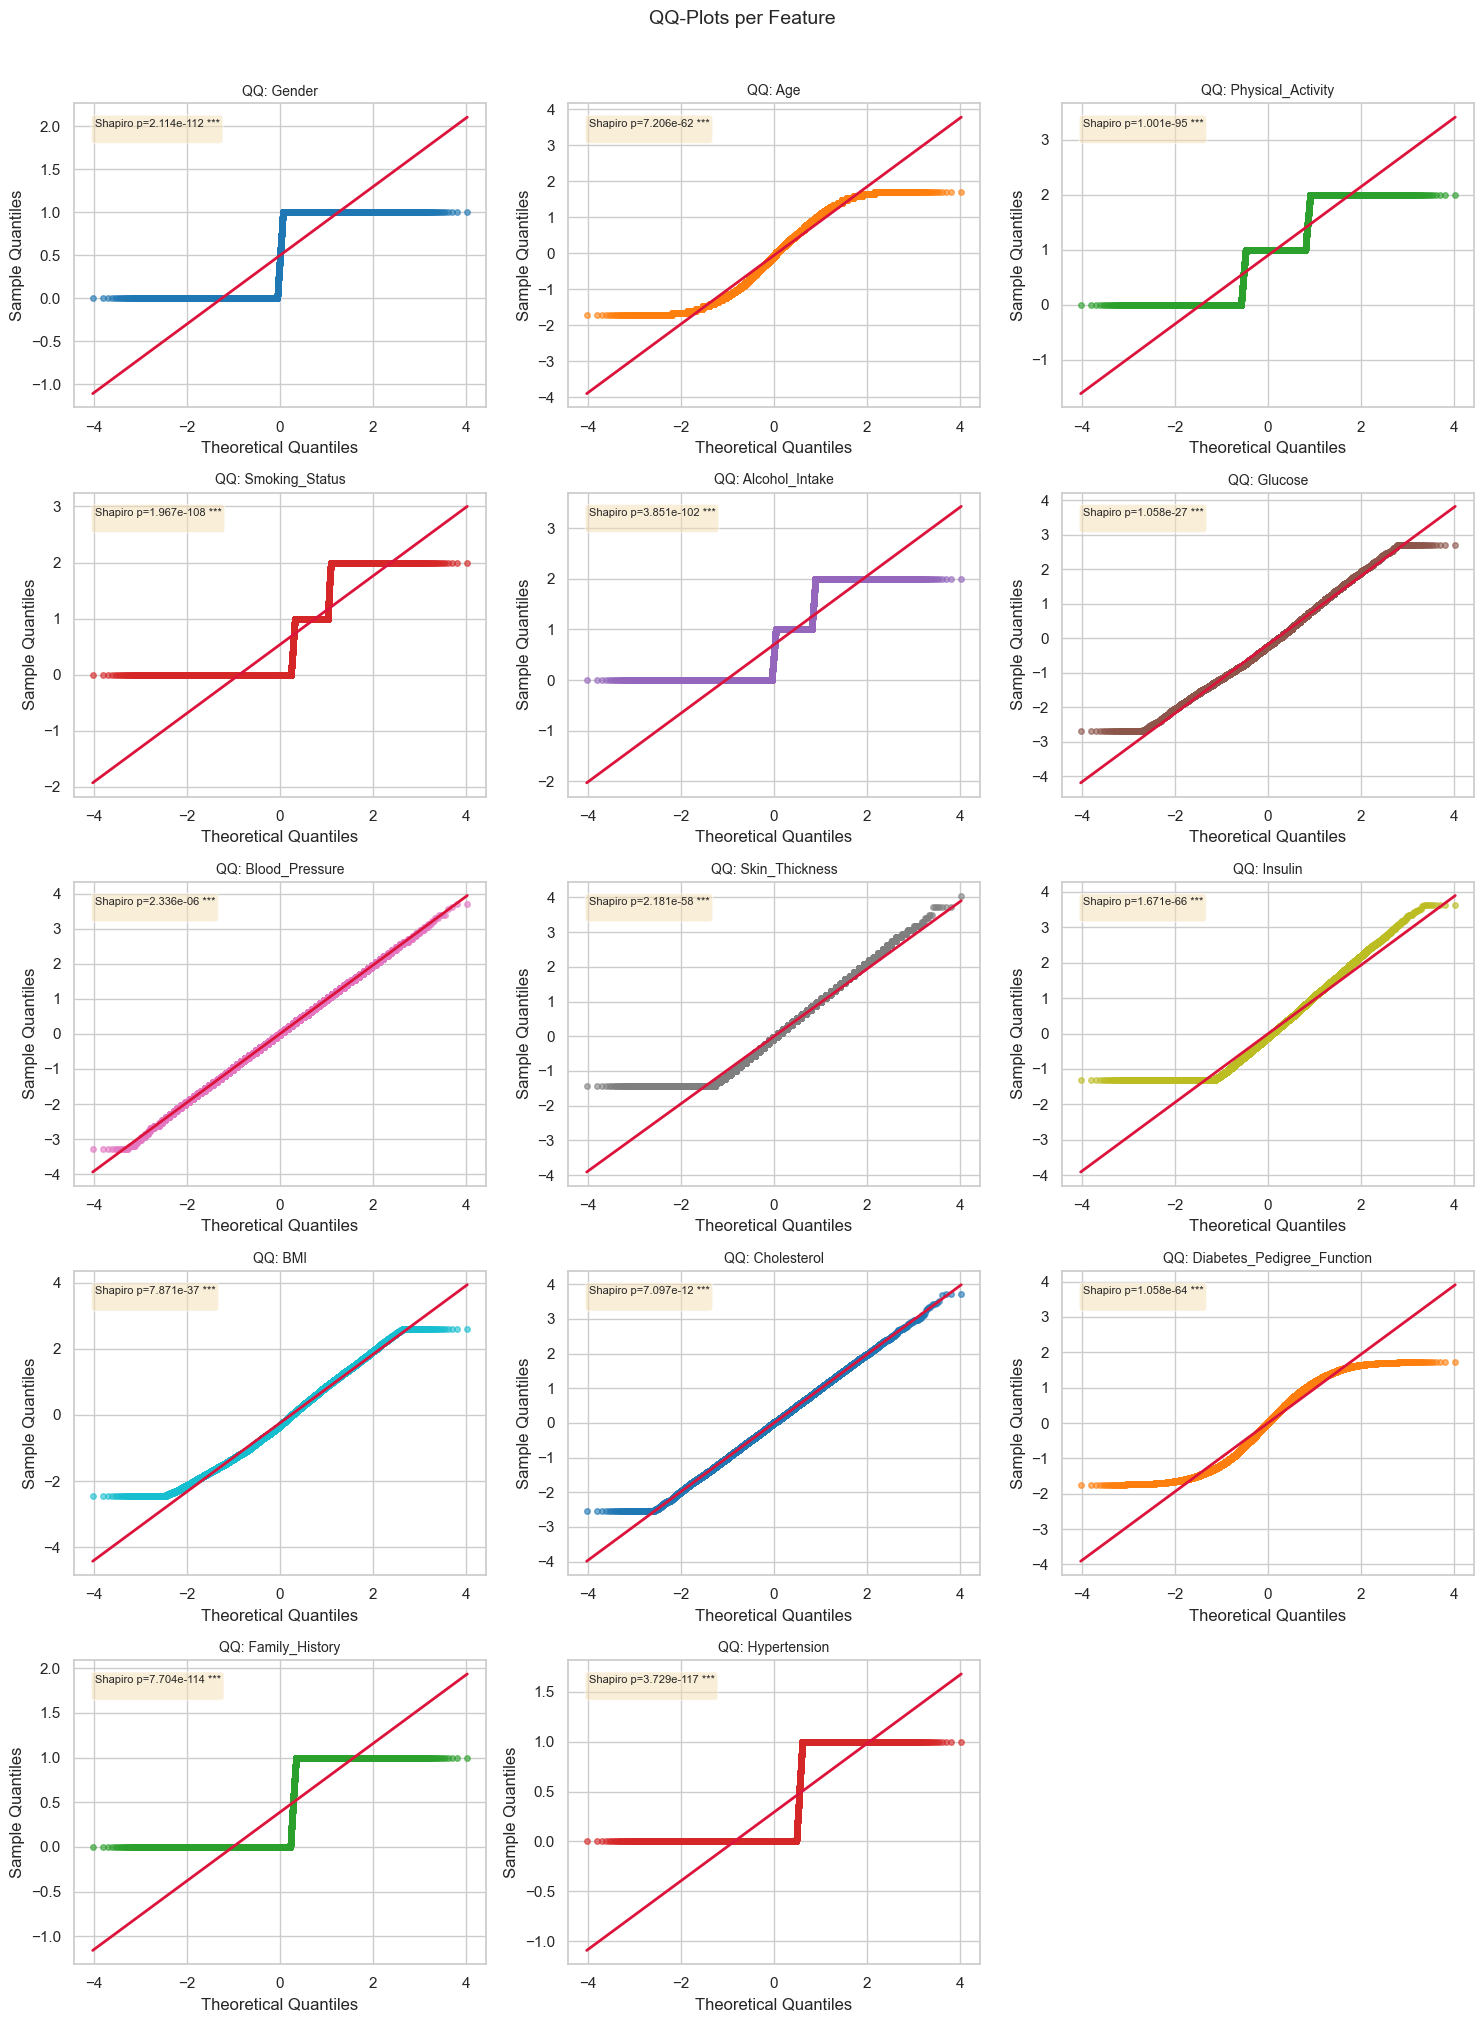

In [149]:
features = [col for col in combined_df.columns if col != 'Risk_Level']

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

colors = plt.cm.tab10.colors

for i, col in enumerate(features):
    ax = axes[i]
    data = combined_df[col].dropna()

    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm", plot=ax)

    ax.get_lines()[0].set(color=colors[i % len(colors)], marker='o', markersize=4, alpha=0.6, linestyle='none')
    ax.get_lines()[1].set(color='crimson', linewidth=2)

    shapiro_stat_all, shapiro_p_all = stats.shapiro(data)

    def sig_label(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else: return 'ns'

    stats_text = (f"Shapiro p={shapiro_p_all:.3e} {sig_label(shapiro_p_all)}\n")
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_title(f'QQ: {col}', fontsize=10)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ-Plots per Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

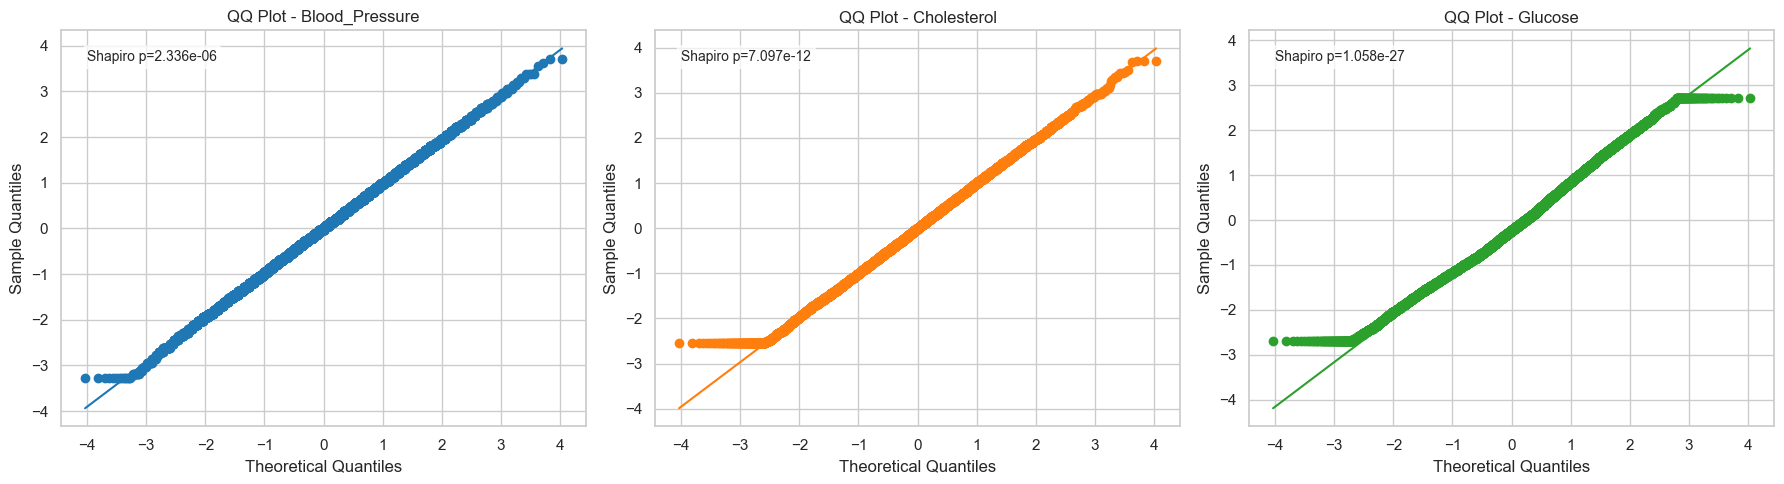

In [150]:
cols = ['Blood_Pressure', 'Cholesterol', 'Glucose']
colors = sns.color_palette("tab10", len(cols))

fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))

for ax, col, color in zip(axes, cols, colors):
    data = combined_df[col].dropna()

    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm", plot=ax)

    # Set different colors for points and line
    ax.get_lines()[0].set_markerfacecolor(color)
    ax.get_lines()[0].set_markeredgecolor(color)
    ax.get_lines()[1].set_color(color)

    # Shapiro-Wilk on a sample if the dataset is large
    # sample = data.sample(5000, random_state=42) if len(data) > 5000 else data
    shapiro_stat, shapiro_p = stats.shapiro(data)
    ax.text(
        0.05,
        0.95,
        f'Shapiro p={shapiro_p:.3e}',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
    )

    ax.set_title(f'QQ Plot - {col}')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

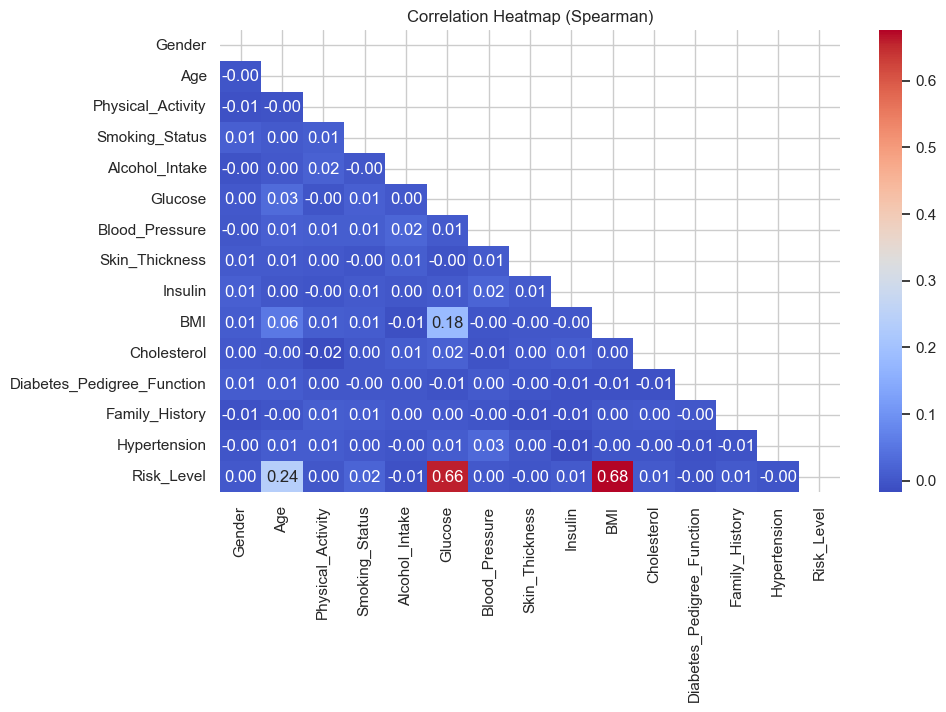

In [151]:
plt.figure(figsize=(10, 6))
corr_matrix = combined_df.corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap (Spearman)')
plt.show()

In [152]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42) 

Train Model


In [153]:
CONFUSION_LABELS = ["L", "M", "H"]

PENALTY_MATRIX = np.array([
     #   L  M  H  predicted
        [0, 1, 2], # L Actual
        [2, 0, 1], # M Actual
        [5, 2, 0]  # H Actual
    ])

NORM_PENALTY_MATRIX = np.array([
        [0, 0.2, 0.4],
        [0.4, 0, 0.2],
        [1, 0.4, 0]
    ])


In [154]:
def cost_sensitive_fit(model, model_name, X_train, X_test, y_train, penalty_matrix=NORM_PENALTY_MATRIX):
    X_train = np.array(X_train)
    X_test  = np.array(X_test)
    y_train = np.array(y_train)

    n_classes = len(np.unique(y_train))

    ridge = model_name == 'OrdinalRidge'

    def to_int(x):
        raw = model.predict(x)
        if ridge:
            return np.clip(np.round(raw).astype(int), 0, n_classes - 1)
        return np.clip(raw.astype(int), 0, n_classes - 1)

    model.fit(X_train, y_train)
    y_initial_pred = to_int(X_test)

    pred = to_int(X_train)
    sample_weights = np.array([penalty_matrix[a][p] for a, p in zip(y_train, pred)])
    sample_weights = np.where(sample_weights == 0, 0.01, sample_weights)
    model.fit(X_train, y_train, sample_weight=sample_weights)
    y_final_pred = to_int(X_test)

    return model, y_initial_pred, y_final_pred

In [155]:
def scoring_before(y_test, y_initial_pred):
    accuracy = round(accuracy_score(y_test, y_initial_pred), 2)
    precision = round(precision_score(y_test, y_initial_pred, average='macro', zero_division=0), 2)
    recall = round(recall_score(y_test, y_initial_pred, average='macro', zero_division=0), 2)
    f1 = round(f1_score(y_test, y_initial_pred, average='macro', zero_division=0), 2)
    return round(accuracy * 0.1 + precision * 0.2 + recall * 0.35 + f1 * 0.35, 2)

def scoring_after(y_test, y_final_pred):
    accuracy = round(accuracy_score(y_test, y_final_pred), 2)
    precision = round(precision_score(y_test, y_final_pred, average='macro', zero_division=0), 2)
    recall = round(recall_score(y_test, y_final_pred, average='macro', zero_division=0), 2)
    f1 = round(f1_score(y_test, y_final_pred, average='macro', zero_division=0), 2)
    return round(accuracy * 0.1 + precision * 0.2 + recall * 0.35 + f1 * 0.35, 2)

In [156]:
def cost_matrix_penalty(y_test, y_pred, cost_matrix=NORM_PENALTY_MATRIX):
    penalties = [cost_matrix[true][pred] for true, pred in zip(y_test, y_pred)]
    total_penalty = np.sum(penalties)
    average_penalty = np.mean(penalties)
    return total_penalty, average_penalty

def evaluate_model(name, y_true, y_pred, y_initial_pred):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'MAE': np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))),
        'Scoring': scoring_after(y_true, y_pred)
    }
    total_penalty, average_penalty = cost_matrix_penalty(y_true, y_pred)
    metrics['Penalty'] = average_penalty

    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, pred, subtitle in zip(axes, [y_initial_pred, y_pred], ['Initial', 'Final']):
        cm = confusion_matrix(y_true, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CONFUSION_LABELS, yticklabels=CONFUSION_LABELS, ax=ax)
        ax.set_title(f'{name} - {subtitle} Prediction')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Accuracy': metrics['Accuracy'], 'Precision': metrics['Precision'], 'Recall': metrics['Recall'], 'F1-Score': metrics['F1-Score'], 'Scoring': metrics['Scoring'], 'MCC': metrics['MCC'], 'MAE': metrics['MAE'], 'Penalty': metrics['Penalty']}

In [157]:
def compare_penalty_tables(y_test, y_initial_pred, y_final_pred, penalty_matrix=NORM_PENALTY_MATRIX):
    def get_penalties(y_true, y_pred):
        return np.array([penalty_matrix[a][p] for a, p in zip(y_true, y_pred)])
    
    initial_penalties = get_penalties(y_test, y_initial_pred)
    final_penalties   = get_penalties(y_test, y_final_pred)
    initial_score = scoring_before(y_test, y_initial_pred)
    final_score = scoring_after(y_test, y_final_pred)
    
    penalty_comparison = pd.DataFrame({
        'Actual': y_test,
        'Predicted (Before P-Matrix)': y_initial_pred,
        'Penalty (Before P-Matrix)': initial_penalties,
        'Predicted (After P-Matrix)': y_final_pred,
        'Penalty (After P-Matrix)': final_penalties,
    })

    before_df = penalty_comparison[['Actual', 'Predicted (Before P-Matrix)', 'Penalty (Before P-Matrix)']].copy()
    after_df = penalty_comparison[['Actual', 'Predicted (After P-Matrix)', 'Penalty (After P-Matrix)']].copy()
    summary_df = pd.DataFrame({
        'Metric': ['Total Penalty', 'Scoring'],
        'Before': [initial_penalties.sum().round(2), initial_score],
        'After': [final_penalties.sum().round(2), final_score]
    })
    summary_df['Difference'] = (summary_df['After'] - summary_df['Before']).abs()
    summary_df['Percentage Changes'] = ((summary_df['Difference'] / summary_df['Before']) * 100).round(2).astype(str) + '%'
    return penalty_comparison, before_df, after_df, summary_df

In [158]:
def model_generalization(model, model_name, X_train, y_train, X_val, y_val, random_state=42):
    train_sizes=np.linspace(0.1, 1.0, 10)
    X_train, y_train, X_val, y_val = np.array(X_train), np.array(y_train), np.array(X_val), np.array(y_val)

    train_scores = []
    val_scores = []
    sizes = []
    gaps = []

    n_train = len(X_train)
    n_classes = len(np.unique(y_train))

    def prepare_predictions(pred):
        return np.clip(np.asarray(pred).astype(int), 0, n_classes - 1)
    
    np.random.seed(random_state)
    index = np.random.permutation(n_train)

    for fraction_train in train_sizes:
        n_samples = int(n_train * fraction_train)
        sizes.append(n_samples)

        X_subset = X_train[index[:n_samples]]
        y_subset = y_train[index[:n_samples]]
        model.fit(X_subset, y_subset)

        train_pred = prepare_predictions(model.predict(X_subset))
        train_score = scoring_before(y_subset, train_pred)

        val_pred = prepare_predictions(model.predict(X_val))
        val_score = scoring_after(y_val, val_pred)

        gap = abs(val_score - train_score)

        train_scores.append(train_score)
        val_scores.append(val_score)
        gaps.append(gap)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(sizes, train_scores, marker='o', label='train score')
    ax[0].plot(sizes, val_scores, marker='o', label='val score')
    ax[0].set_xticks(sizes)
    ax[0].set_xticklabels([f'{int(f*100)}%' for f in train_sizes], rotation=45, fontsize=8)
    ax[0].set_xlabel('Training samples')
    ax[0].set_ylabel('Score')
    ax[0].set_title(f'Learning curve - {model_name}')
    ax[0].legend()
    ax[0].grid(alpha=0.2)

    ax[1].plot(sizes, gaps, marker='o', linewidth=2)
    ax[1].set_xticks(sizes)
    ax[1].set_xticklabels([f'{int(f*100)}%' for f in train_sizes], rotation=45, fontsize=8)
    ax[1].set_xlabel('Training samples')
    ax[1].set_ylabel('Score gap')
    ax[1].set_title(f'Score gap - {model_name}')
    ax[1].grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()

In [159]:
def paired_penalty_ttest(penalty_comparison):
    before = penalty_comparison['Penalty (Before P-Matrix)'].tolist()
    after = penalty_comparison['Penalty (After P-Matrix)'].tolist()
    t_stat, p_value = stats.ttest_rel(before, after)
    return t_stat, p_value

In [160]:
def evaluate_performance(results):
    df_temp = pd.DataFrame(results)
    df_results = df_temp[['Model', 'Scoring', 'MCC', 'Penalty', 'MAE']].copy()
    return df_results

def statement(Model, Score, MCC, Penalty, MAE):
    P = ['T' if s < m else 'F' for s, m in zip(Score, MCC)]
    Q = ['T' if p < a else 'F' for p, a in zip(Penalty, MAE)]
    return pd.DataFrame({'Model': Model, 'P': P, 'Q': Q})

In [161]:
results = []

# Logistic Regression (Nominal Model)


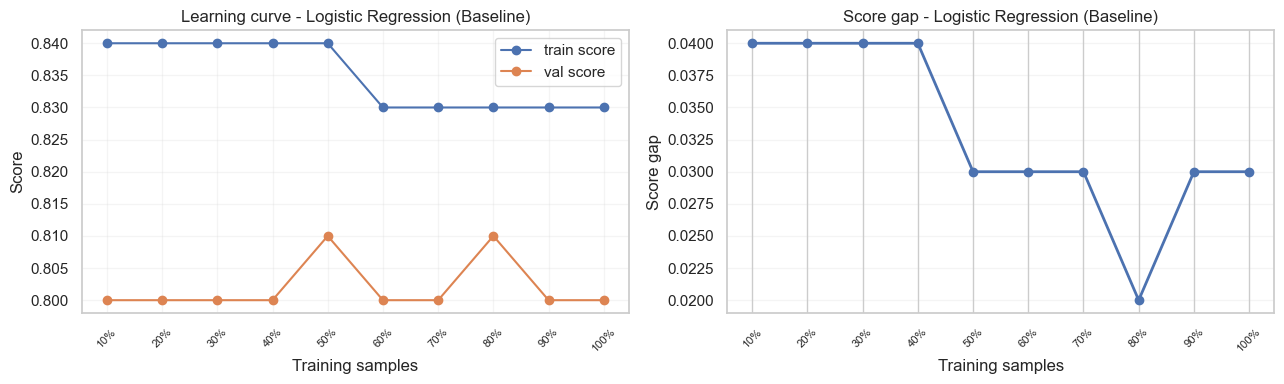

Accuracy: 0.78
Precision: 0.76
Recall: 0.81
F1 Score: 0.78
Scoring: 0.79


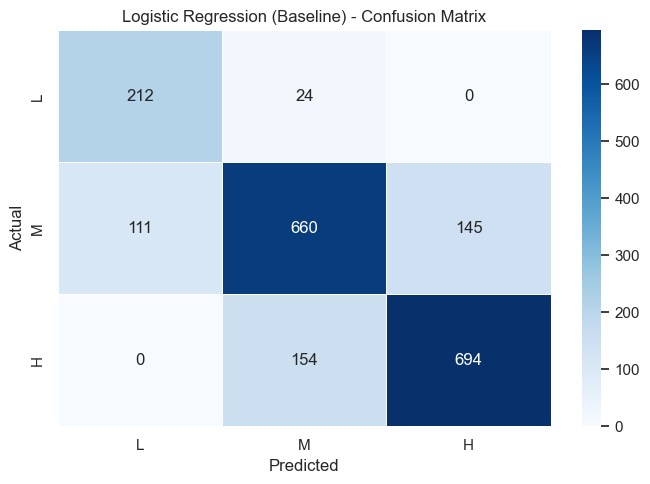

In [162]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
result = model_generalization(log_model, 'Logistic Regression (Baseline)', X_train, y_train, X_val, y_val)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, average='macro', zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, average='macro', zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_log, average='macro', zero_division=0),
    "Scoring": scoring_after(y_test, y_pred_log)
}

for name, value in metrics.items():
    print(f"{name}: {value:.2f}")

cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CONFUSION_LABELS, yticklabels=CONFUSION_LABELS, linewidths=0.5, cbar=True)

plt.title('Logistic Regression (Baseline) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 1. MORD LogisticIT (Ordinal Model)


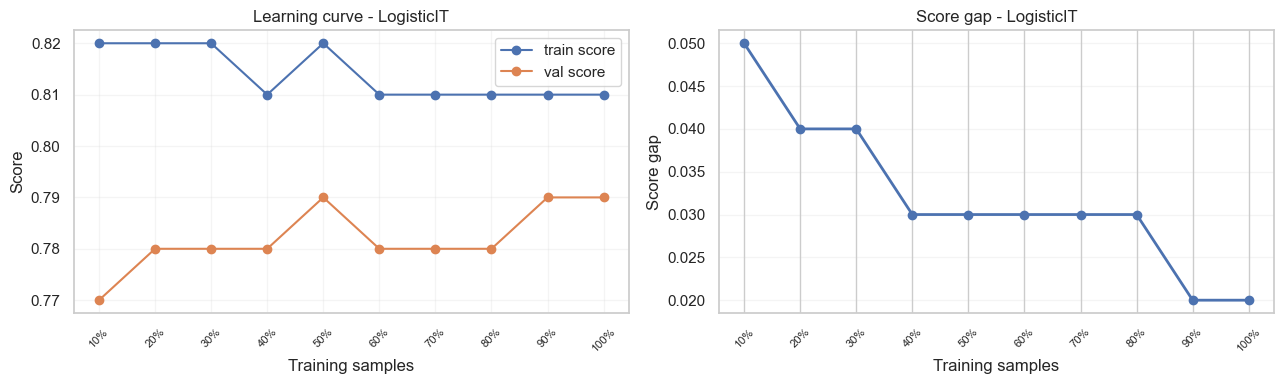

Accuracy: 0.7355
Precision: 0.7948
Recall: 0.6105
F1-Score: 0.6246
MCC: 0.5456
MAE: 0.2645
Scoring: 0.6600
Penalty: 0.0599


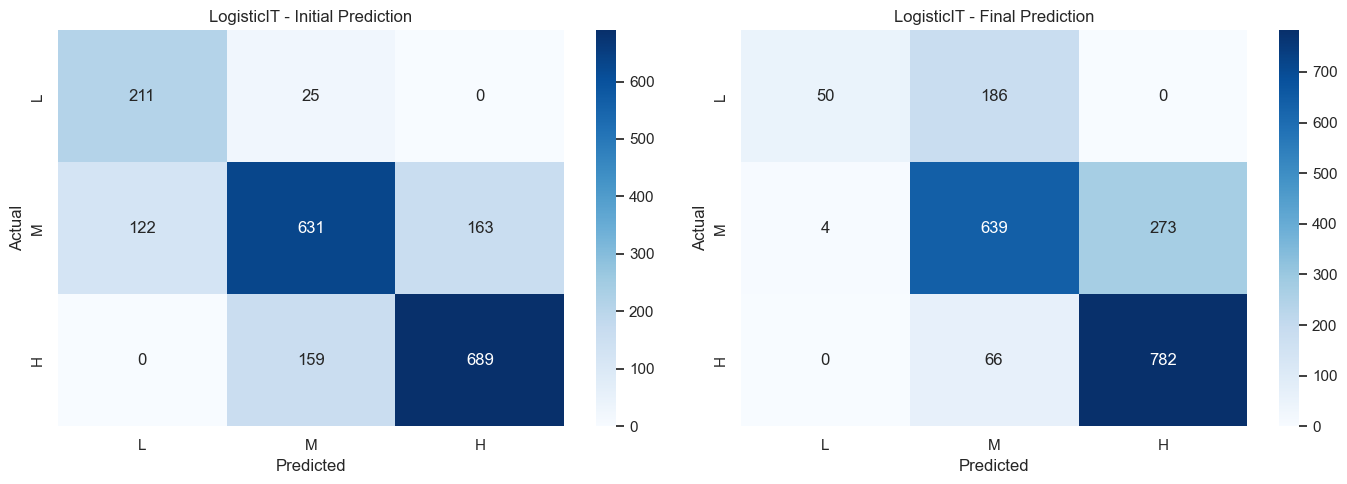

T-statistic: 4.5443
P-value: 5.842e-06


In [163]:
model, y_initial_pred, y_final_pred = cost_sensitive_fit(LogisticIT(), "LogisticIT", X_train, X_test, y_train)
comparison, before_df, after_df, summary_df = compare_penalty_tables(y_test, y_initial_pred, y_final_pred)

result = model_generalization(model, 'LogisticIT', X_train, y_train, X_val, y_val)
results.append(evaluate_model('LogisticIT', y_test, y_final_pred, y_initial_pred))

t_stat, p_value = paired_penalty_ttest(comparison)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.3e}")

In [164]:
summary_df

,Metric,Before,After,Difference,Percentage Changes
0,Total Penalty,150.00,119.80,30.20,20.13%
1,Scoring,0.77,0.66,0.11,14.29%


# 2. LogisticAT (Ordinal Model)

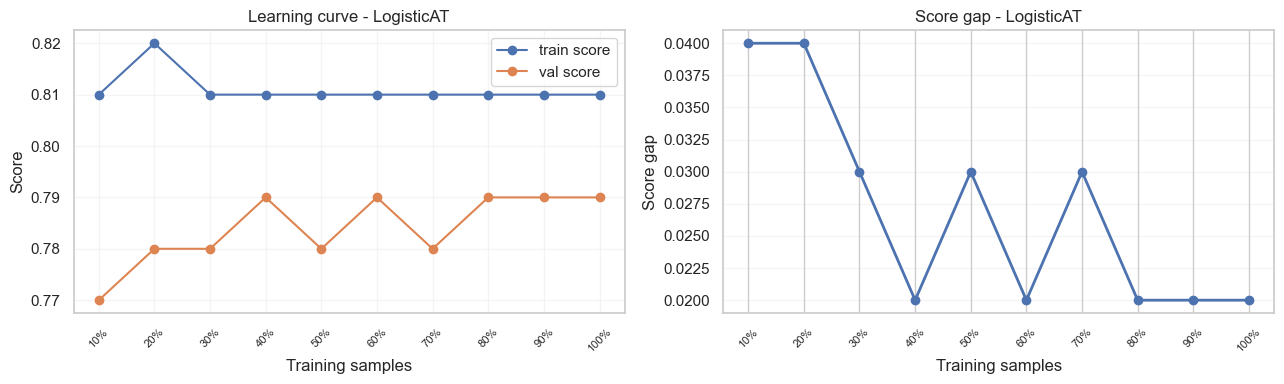

Accuracy: 0.7475
Precision: 0.8017
Recall: 0.6291
F1-Score: 0.6503
MCC: 0.5642
MAE: 0.2525
Scoring: 0.6800
Penalty: 0.0600


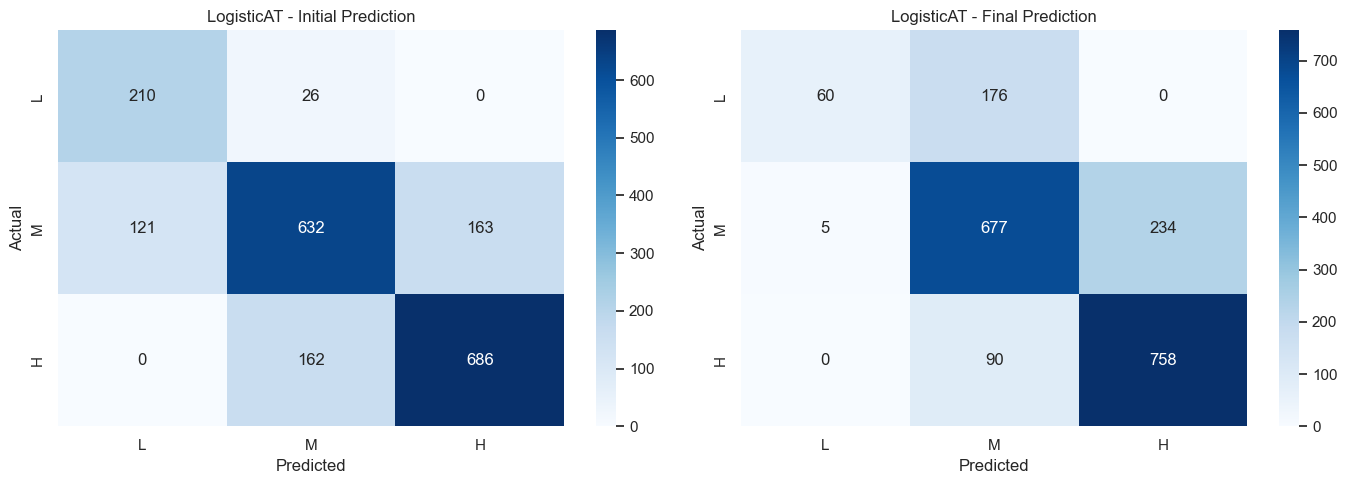

T-statistic: 4.9988
P-value: 6.272e-07


In [165]:
model, y_initial_pred, y_final_pred = cost_sensitive_fit(LogisticAT(), "LogisticAT", X_train, X_test, y_train)
comparison, before_df, after_df, summary_df = compare_penalty_tables(y_test, y_initial_pred, y_final_pred)

result = model_generalization(model, 'LogisticAT', X_train, y_train, X_val, y_val)
results.append(evaluate_model('LogisticAT', y_test, y_final_pred, y_initial_pred))

t_stat, p_value = paired_penalty_ttest(comparison)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.3e}")

In [166]:
summary_df

,Metric,Before,After,Difference,Percentage Changes
0,Total Penalty,151.00,120.00,31.00,20.53%
1,Scoring,0.77,0.68,0.09,11.69%


# 3. LogisticSE (Ordinal Model)

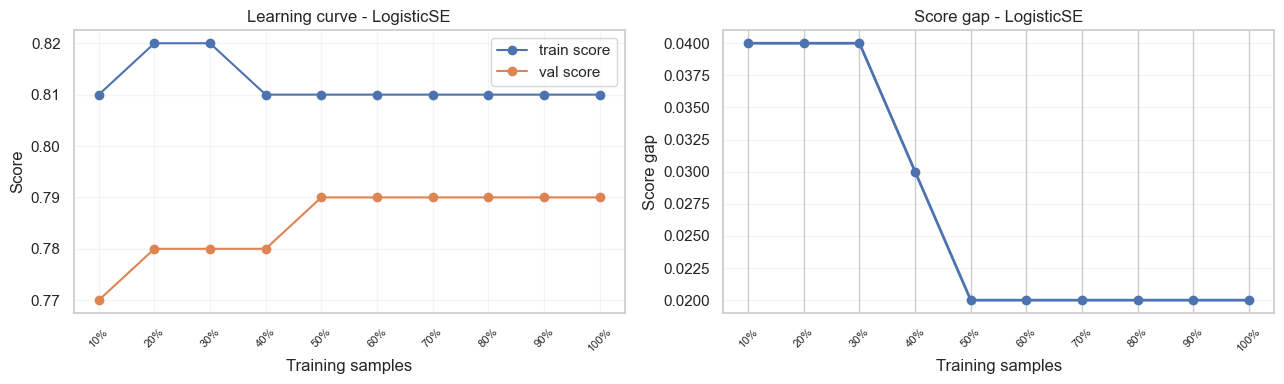

Accuracy: 0.7560
Precision: 0.8087
Recall: 0.6546
F1-Score: 0.6839
MCC: 0.5792
MAE: 0.2440
Scoring: 0.7000
Penalty: 0.0603


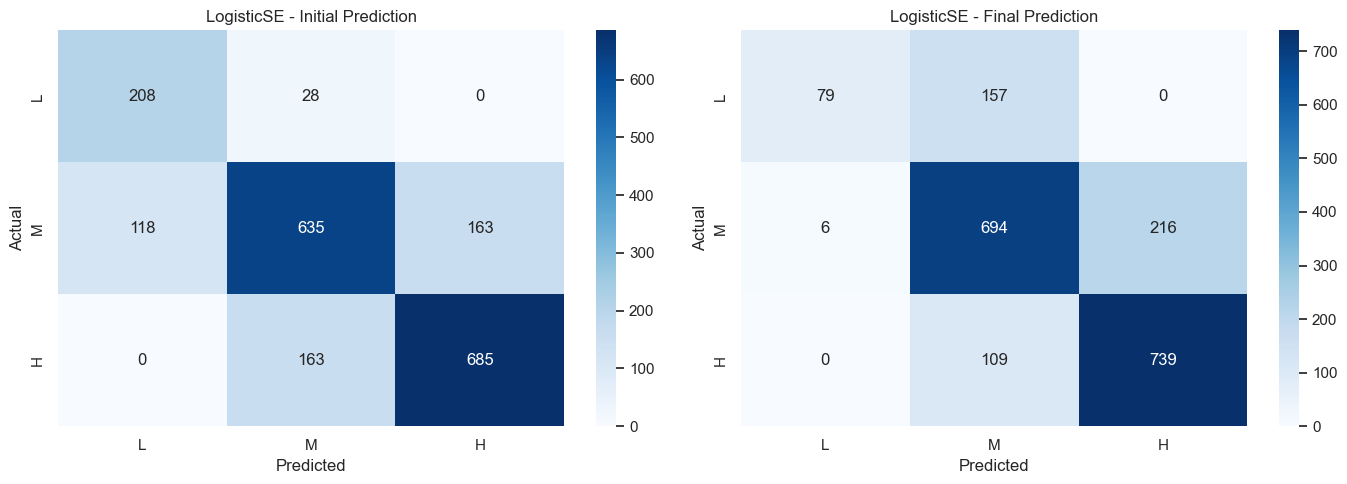

T-statistic: 5.1904
P-value: 2.311e-07


In [167]:
model, y_initial_pred, y_final_pred = cost_sensitive_fit(LogisticSE(), "LogisticSE", X_train, X_test, y_train)
comparison, before_df, after_df, summary_df = compare_penalty_tables(y_test, y_initial_pred, y_final_pred)

result = model_generalization(model, 'LogisticSE', X_train, y_train, X_val, y_val)
results.append(evaluate_model('LogisticSE', y_test, y_final_pred, y_initial_pred))

t_stat, p_value = paired_penalty_ttest(comparison)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.3e}")

In [168]:
summary_df

,Metric,Before,After,Difference,Percentage Changes
0,Total Penalty,150.60,120.6,30.00,19.92%
1,Scoring,0.77,0.7,0.07,9.09%


## 4. OrdinalRidge (Ordinal Model)


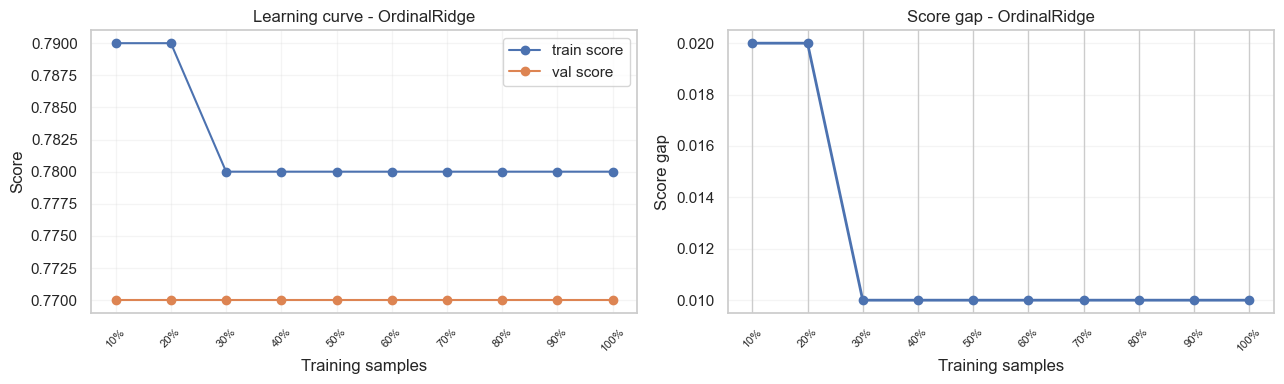

Accuracy: 0.7650
Precision: 0.7911
Recall: 0.7093
F1-Score: 0.7339
MCC: 0.6044
MAE: 0.2350
Scoring: 0.7400
Penalty: 0.0569


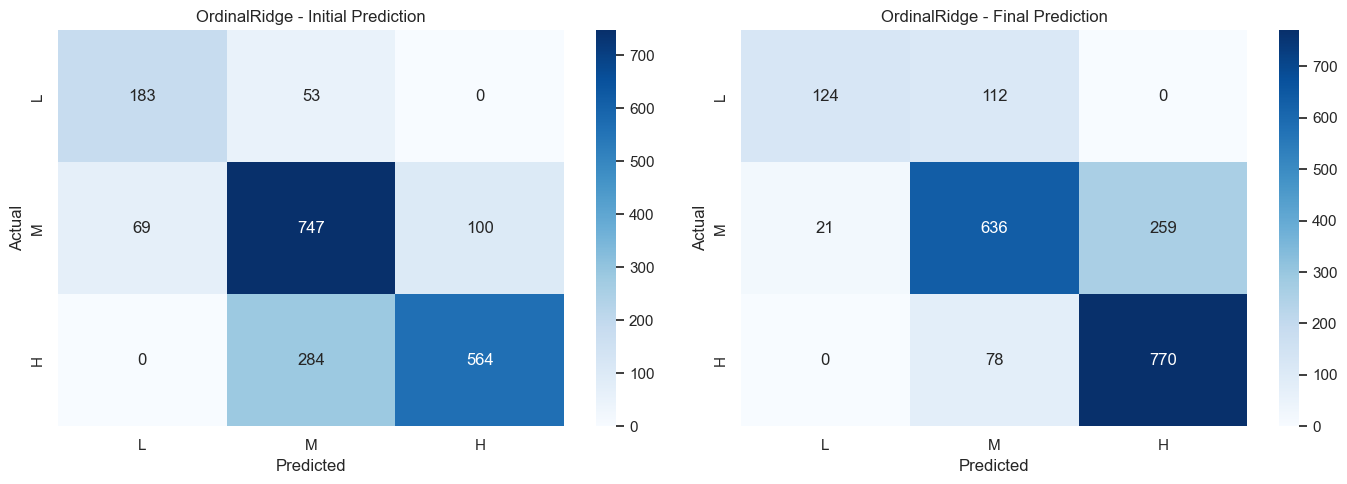

T-statistic: 8.3977
P-value: 8.506e-17


In [169]:
model, y_initial_pred, y_final_pred = cost_sensitive_fit(OrdinalRidge(), "OrdinalRidge", X_train, X_test, y_train)
comparison, before_df, after_df, summary_df = compare_penalty_tables(y_test, y_initial_pred, y_final_pred)

result = model_generalization(model, 'OrdinalRidge', X_train, y_train, X_val, y_val)
results.append(evaluate_model('OrdinalRidge', y_test, y_final_pred, y_initial_pred))

t_stat, p_value = paired_penalty_ttest(comparison)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.3e}")

In [170]:
summary_df

,Metric,Before,After,Difference,Percentage Changes
0,Total Penalty,171.80,113.80,58.00,33.76%
1,Scoring,0.75,0.74,0.01,1.33%


In [171]:
results_df = pd.DataFrame(results)

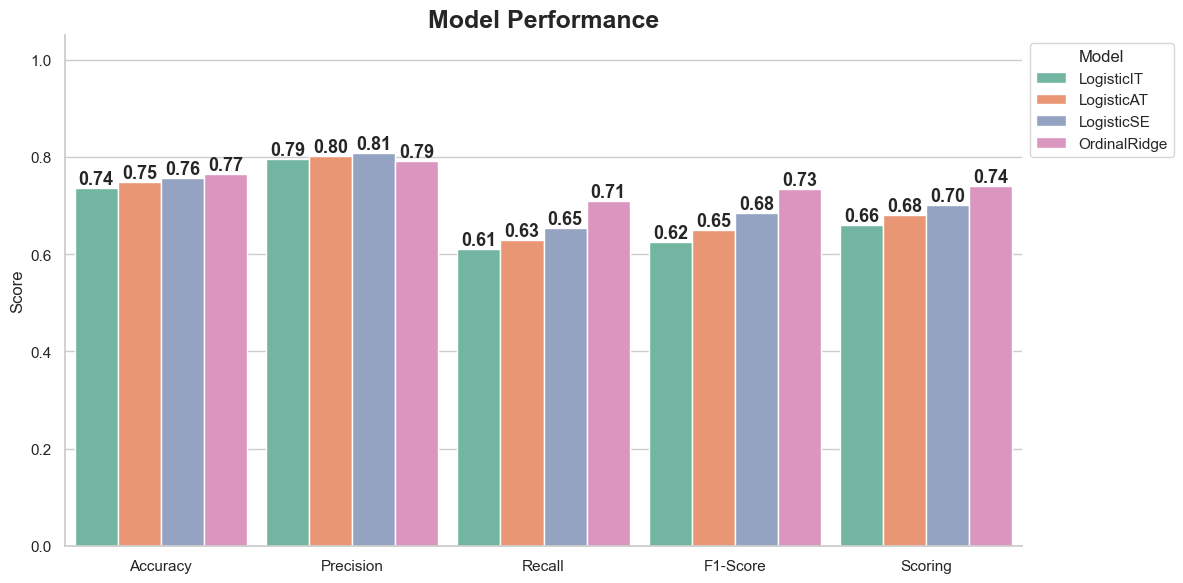

In [172]:
metric_group1 = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'Scoring'
]

plot_df = results_df.melt(id_vars='Model', value_vars=metric_group1, var_name='Metric', value_name='Score')

plt.figure(figsize=(12,6))
sns.set_theme(style='whitegrid')

ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='Set2', width=0.9)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=13, fontweight='bold')

plt.title('Model Performance', fontsize=18, fontweight='bold', loc='center')

plt.xlabel('')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

In [173]:
df_results = evaluate_performance(results)
df_results

,Model,Scoring,MCC,Penalty,MAE
0,LogisticIT,0.66,0.545596,0.0599,0.2645
1,LogisticAT,0.68,0.564180,0.0600,0.2525
2,LogisticSE,0.70,0.579229,0.0603,0.2440
3,OrdinalRidge,0.74,0.604364,0.0569,0.2350


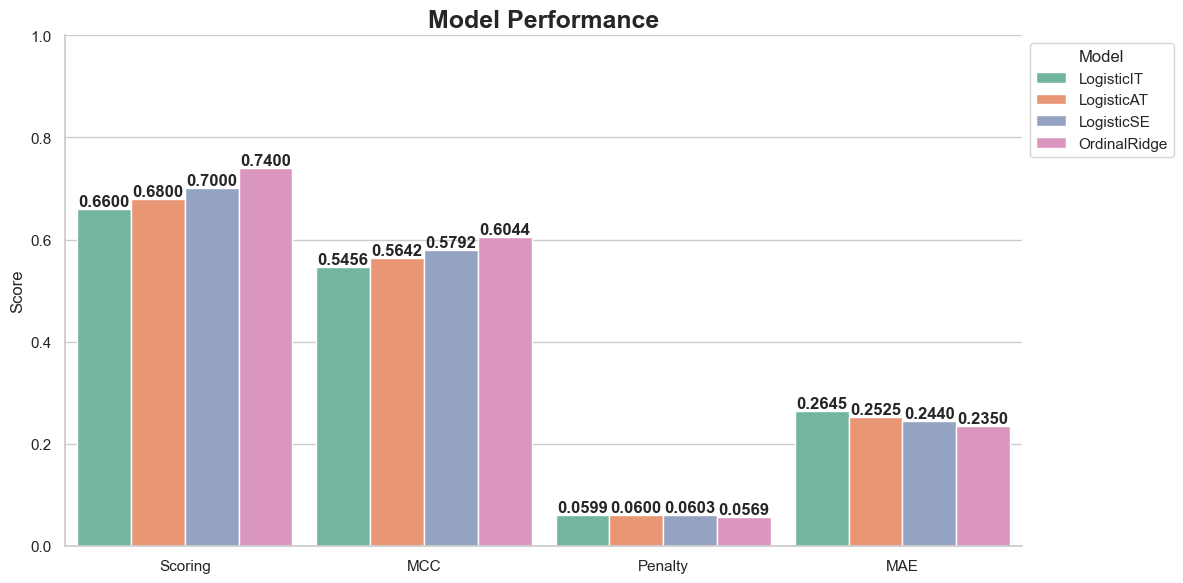

In [174]:
metric_group2 = [
    'Scoring',
    'MCC',
    'Penalty',
    'MAE'
]


plot_df = results_df.melt(id_vars='Model', value_vars=metric_group2, var_name='Metric', value_name='Score')

plt.figure(figsize=(12,6))
sns.set_theme(style='whitegrid')

ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='Set2', width=0.9)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=12, fontweight='bold')

plt.title('Model Performance', fontsize=18, fontweight='bold', loc='center')

plt.xlabel('')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

In [175]:
df_results_2 = statement(df_results['Model'], df_results['Scoring'], df_results['MCC'], df_results['Penalty'], df_results['MAE'])
df_results_2

,Model,P,Q
0,LogisticIT,F,T
1,LogisticAT,F,T
2,LogisticSE,F,T
3,OrdinalRidge,F,T
